<a href="https://colab.research.google.com/github/AivinBinoy/AivinBinoy/blob/main/Task_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌸 Iris Species Classification using Machine Learning

## 📌 Project Overview
This project classifies Iris flower species using machine learning classification algorithms.

## 🎯 Objective
To implement and compare SVM, KNN, and Random Forest classifiers on the Iris dataset.

## 🤖 Models Used
- Support Vector Machine - Linear Kernel
- Support Vector Machine - RBF Kernel
- Support Vector Machine - Sigmoid Kernel
- Support Vector Machine - Polynomial Kernel
- K-Nearest Neighbors
- Random Forest Classifier

## 📊 Evaluation Metrics
- Accuracy Score
- Confusion Matrix

## 👤 Submitted By
Aivin Binoy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

# 1️⃣ Loading the Dataset
The Iris dataset is loaded into a Pandas DataFrame.

In [ ]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# 2️⃣ Dataset Exploration
Checking dataset structure, statistical summary, and missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


# 3️⃣ Data Preprocessing
Unnecessary columns are removed and the dataset is prepared for model training.

In [ ]:
# Remove Id column if present
if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# 4️⃣ Splitting Features and Target
The independent features are stored in X and the target species column is stored in y.

In [ ]:
X = df.drop('Species', axis=1)
y = df['Species']

# 5️⃣ Train-Test Split
The dataset is divided into training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6️⃣ Feature Scaling
Feature scaling is applied because SVM and KNN are sensitive to feature ranges.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7️⃣ Training SVM Models
SVM models are trained using Linear, RBF, Sigmoid, and Polynomial kernels.

In [ ]:
kernels = ['linear', 'rbf', 'sigmoid', 'poly']
svm_results = {}

for kernel in kernels:
    svm_model = SVC(kernel=kernel)
    svm_model.fit(X_train_scaled, y_train)

    y_pred = svm_model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    svm_results[kernel] = accuracy

    print(f"SVM Kernel: {kernel}")
    print("Accuracy:", accuracy)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)

SVM Kernel: linear
Accuracy: 0.9666666666666667
Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
--------------------------------------------------
SVM Kernel: rbf
Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
--------------------------------------------------
SVM Kernel: sigmoid
Accuracy: 0.9
Confusion Matrix:
[[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]
--------------------------------------------------
SVM Kernel: poly
Accuracy: 0.9666666666666667
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  1 10]]
--------------------------------------------------


# 8️⃣ Training KNN Model
K-Nearest Neighbors classifier is trained on the scaled dataset.

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

KNN Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


# 9️⃣ Training Random Forest Model
Random Forest is selected as the additional classification algorithm.

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


# 🔟 Model Comparison
A comparison table is created to identify the best-performing model.

In [ ]:
results = pd.DataFrame({
    'Model': [
        'SVM Linear',
        'SVM RBF',
        'SVM Sigmoid',
        'SVM Polynomial',
        'KNN',
        'Random Forest'
    ],
    'Accuracy': [
        svm_results['linear'],
        svm_results['rbf'],
        svm_results['sigmoid'],
        svm_results['poly'],
        knn_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,SVM Linear,0.966667
1,SVM RBF,1.000000
2,SVM Sigmoid,0.900000
3,SVM Polynomial,0.966667
4,KNN,1.000000
5,Random Forest,1.000000


# 1️⃣1️⃣ Accuracy Comparison Graph
A bar chart is used to visually compare model accuracy.

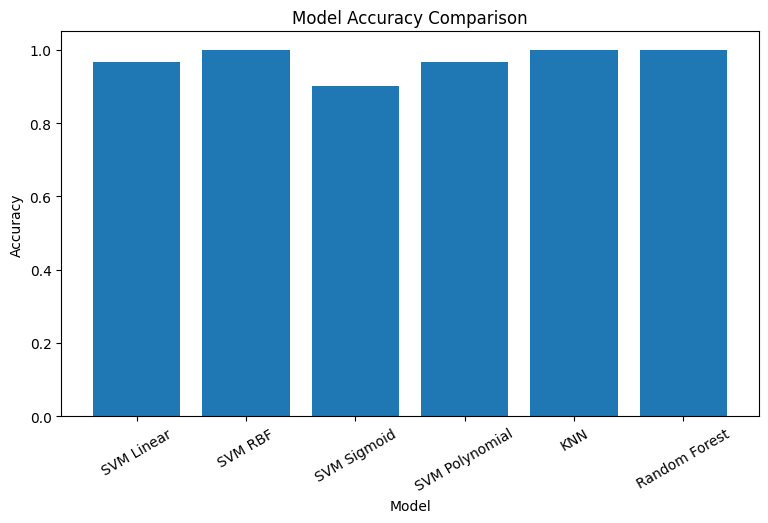

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(results['Model'], results['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=30)
plt.show()

# 🌲 Random Forest Algorithm Explanation

## How Random Forest Works
Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their outputs to make a final prediction.

Each tree is trained on different random samples of the data. For classification, the final class is selected based on majority voting from all trees.

## Key Assumptions
- The dataset contains useful features for classification.
- Combining many decision trees improves prediction stability.
- Individual trees may make errors, but the overall forest reduces those errors.

## Strengths
- Handles non-linear data well.
- Reduces overfitting compared to a single decision tree.
- Works well with both small and large datasets.
- Provides strong classification performance.

## Limitations
- Less interpretable than a single decision tree.
- Requires more computation than simple models.
- May not perform well if the dataset has many irrelevant features.

## Suitable Situations
Random Forest performs well when the relationship between features and target is complex and non-linear.

## Unsuitable Situations
It may not be suitable when high interpretability is required or when computational resources are very limited.

# 🔍 Observations

- SVM, KNN, and Random Forest were successfully implemented.
- SVM was tested using Linear, RBF, Sigmoid, and Polynomial kernels.
- KNN performed well because Iris is a small and well-separated dataset.
- Random Forest performed strongly by combining multiple decision trees.
- Sigmoid kernel may perform lower compared to Linear and RBF kernels.
- Accuracy score and confusion matrix were used to evaluate all models.

# ✅ Final Conclusion

The Iris species classification task was successfully completed using SVM, KNN, and Random Forest classifiers.

SVM with Linear or RBF kernel usually performs well for the Iris dataset because the classes are fairly separable.

KNN also performs effectively because it classifies samples based on nearby similar data points.

Random Forest is a strong additional algorithm because it combines multiple decision trees and improves prediction stability.

Overall, the best model can be selected by comparing accuracy scores and confusion matrices.